# ⛽📈 Моделирование временных рядов

![Нефть и газ](https://avatars.mds.yandex.net/i?id=f0c6e485cc98b2d1ee4633e48d076c80_l-5315578-images-thumbs&n=13.jpg)


# <center> 🔄 Загрузка библиотек <center>

In [1]:
import numpy as np 
import pandas as pd

from statsmodels.tsa.api import VAR
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests, acf
from statsmodels.graphics.tsaplots import plot_acf

from statsmodels.api import add_constant, OLS

from sklearn.model_selection import TimeSeriesSplit

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, root_mean_squared_error

import warnings        
warnings.filterwarnings('ignore')

import optuna
from prophet import Prophet

In [2]:
def check_stationarity(series, commodity, alpha=0.05,):
    """
    Проверка стационарности временного ряда
    
    Args:
        series (pd.Series): Временной ряд
        alpha (float): Уровень значимости
        method (str): 'adf', 'kpss' или 'both'
    
    Returns:
        dict: Результаты тестов
    """
    
    # Тест Дики-Фуллера (ADF)
    adf_result = adfuller(series, autolag='AIC')
    
    # Тест KPSS
    kpss_result = kpss(series, regression='c', nlags='auto')

    # Интерпретация результатов
    print(f"Результаты проверки стационарности {commodity}:\n")
    print(f"Уровень значимости: {alpha}")
    print(f"Тест Дики-Фуллера (ADF): pvalue= {kpss_result[1]:.4f}")
    print(f"Тест KPSS: p-value = {kpss_result[1]:.4f}")

    # Совместная интерпретация
    adf_stationary = adf_result[1] < alpha
    kpss_stationary = kpss_result[1] > alpha
    
    if adf_stationary and kpss_stationary:
        print(f'Вывод: Ряд стационарен {commodity}\n')
    elif not adf_stationary and not kpss_stationary:
        print(f'Вывод: Ряд нестационарен (тренд) {commodity}\n')
    elif adf_stationary and not kpss_stationary:
        print(f'Вывод: Ряд стационарен вокруг детерминированного тренда {commodity}\n')
    else:
        print(f'Вывод: Результаты противоречивы {commodity}\n')

# Предобработка

Результаты проверки стационарности oil:

Уровень значимости: 0.05
Тест Дики-Фуллера (ADF): pvalue= 0.1000
Тест KPSS: p-value = 0.1000
Вывод: Ряд стационарен oil

Результаты проверки стационарности gas:

Уровень значимости: 0.05
Тест Дики-Фуллера (ADF): pvalue= 0.0417
Тест KPSS: p-value = 0.0417
Вывод: Ряд нестационарен (тренд) gas



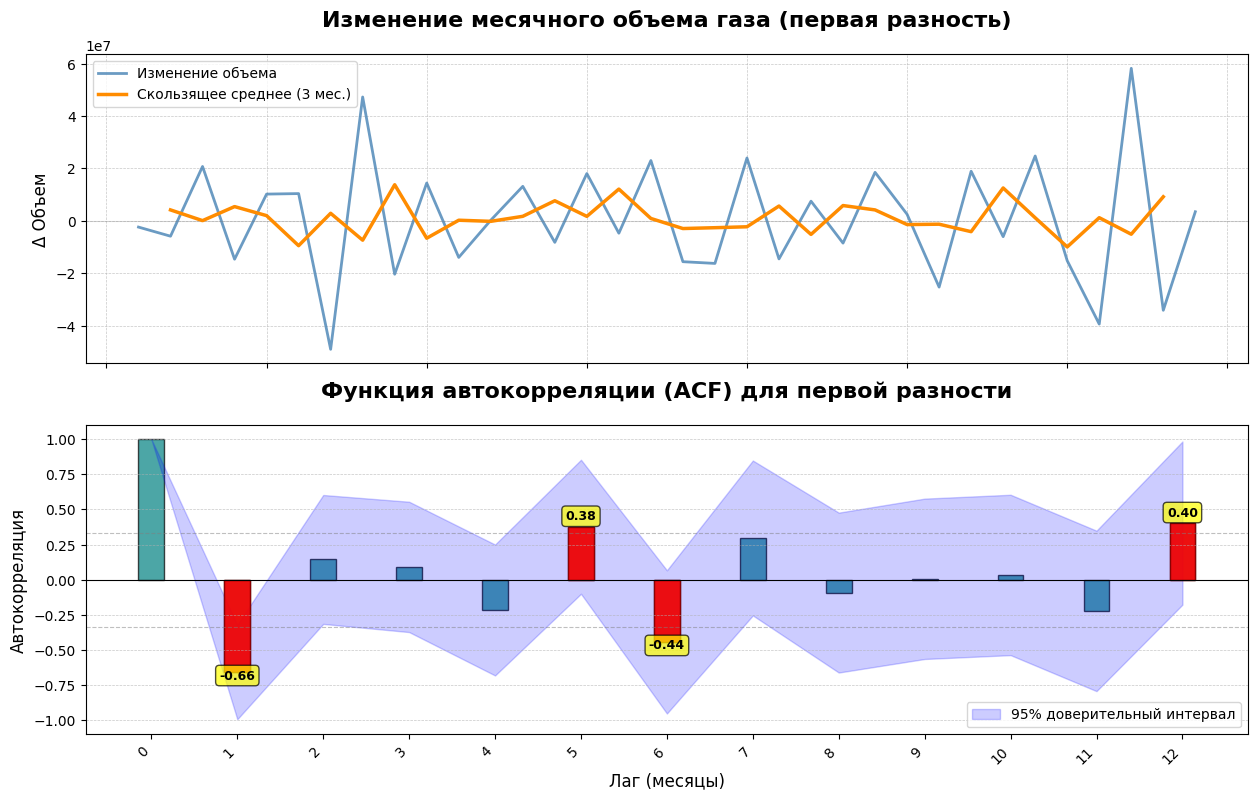

In [68]:
oil_monthly = pd.read_csv('../data/processed/oil_monthly_break.csv')
gas_monthly= pd.read_csv('../data/processed/gas_monthly_break.csv')

oil_monthly.rename(columns={'Production Date': 'period'}, inplace=True)
gas_monthly.rename(columns={'Production Date': 'period'}, inplace=True)

oil_monthly['period'] = pd.to_datetime(oil_monthly['period']).dt.to_period('M')
gas_monthly['period'] = pd.to_datetime(gas_monthly['period']).dt.to_period('M')

check_stationarity(oil_monthly['Volume'].diff().dropna(), commodity='oil')
check_stationarity(gas_monthly['Volume'].diff().dropna(), commodity='gas')

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

diff_series = gas_monthly['Volume'].diff(1).dropna() 

axes[0].plot(diff_series.index, diff_series.values, 
             linewidth=2, color='steelblue', alpha=0.8, label='Изменение объема')
axes[0].axhline(y=0, color='gray', linestyle='-', alpha=0.3, linewidth=0.8)

window = 3  
rolling_mean = diff_series.rolling(window=window, center=True).mean()
axes[0].plot(rolling_mean.index, rolling_mean.values, 
             color='darkorange', linewidth=2.5, 
             label=f'Скользящее среднее ({window} мес.)')

axes[0].set_title('Изменение месячного объема газа (первая разность)', 
                  fontsize=16, fontweight='bold', pad=20)
axes[0].set_xlabel('Дата', fontsize=12)
axes[0].set_ylabel('Δ Объем', fontsize=12)
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
axes[0].legend(loc='best', fontsize=10)
axes[0].tick_params(axis='both', which='major', labelsize=10)

fig.autofmt_xdate(rotation=45, ha='right')

# Вычисляем ACF с доверительными интервалами
nlags = 12
acf_values, confint = acf(diff_series, nlags=nlags, fft=False, alpha=0.05)

lags = np.arange(len(acf_values))
axes[1].bar(lags, acf_values, width=0.3, color='teal', alpha=0.7, edgecolor='black')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)

conf_lower = confint[:, 0] - acf_values
conf_upper = confint[:, 1] - acf_values
axes[1].fill_between(lags, acf_values + conf_lower, acf_values + conf_upper, 
                     alpha=0.2, color='blue', label='95% доверительный интервал')

significant_lags = lags[np.abs(acf_values) > 1.96/np.sqrt(len(diff_series))]
for lag in significant_lags:
    if lag > 0:  
        axes[1].bar(lag, acf_values[lag], width=0.3, color='red', alpha=0.9, edgecolor='darkred')

# Настройка ACF графика
axes[1].set_title('Функция автокорреляции (ACF) для первой разности', 
                  fontsize=16, fontweight='bold', pad=20)
axes[1].set_xlabel('Лаг (месяцы)', fontsize=12)
axes[1].set_ylabel('Автокорреляция', fontsize=12)
axes[1].set_xticks(lags)
axes[1].set_xticklabels([f'{int(lag)}' for lag in lags])
axes[1].grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
axes[1].legend(loc='best', fontsize=10)
axes[1].set_ylim([-1.1, 1.1])
axes[1].axhline(y=1.96/np.sqrt(len(diff_series)), color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
axes[1].axhline(y=-1.96/np.sqrt(len(diff_series)), color='gray', linestyle='--', alpha=0.5, linewidth=0.8)

for lag in significant_lags:
    if lag > 0:
        axes[1].text(lag, acf_values[lag] + 0.05 * np.sign(acf_values[lag]), 
                    f'{acf_values[lag]:.2f}', 
                    ha='center', fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

### Проверка стационарности (период: 2022–07 → 2025–05)

| Ряд | ADF p-value | KPSS p-value | Вывод |
|------|--------------|--------------|--------|
| **Oil (Δ)** | 0.1000 | 0.1000 | Стационарен |
| **Gas (Δ)** | 0.0417 | 0.0417 | Гранично-стационарен |

После первого дифференцирования ряд нефти (Oil) демонстрирует признаки стационарности
по обоим тестам (ADF и KPSS).

Ряд газа (Gas) после первого дифференцирования показывает смешанные результаты.

С учётом:
- короткой длины выборки,
- отсутствия взрывной динамики,
- быстро затухающей автокорреляции,
- и значимого лага первого порядка,

Ряд Gas в первых разностях принимается как *условно стационарный*
(weakly stationary), что позволяет использовать модель VAR,
построенную на первых разностях (VAR(Δ)).

Исходные данные:
Размер: (34, 2)
Период: 2022-08 - 2025-05


,Oil_diff,Gas_diff
period,,
2022-08,1870021.0,-2376753.0
2022-09,-97953.0,-5853458.0
2022-10,3662619.0,20750535.0
2022-11,-4060782.0,-14634775.0
2022-12,2034367.0,10209750.0



Разделение на train/test:
Train: 31 наблюдений (2022-08 - 2025-02)
Test:  3 наблюдений (2025-03 - 2025-05)

ПОСТРОЕНИЕ VAR МОДЕЛИ ДЛЯ НЕФТИ И ГАЗА

Результаты модели VAR:
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 05, Jan, 2026
Time:                     13:15:14
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    63.2915
Nobs:                     30.0000    HQIC:                   63.1009
Log likelihood:          -1024.31    FPE:                2.32291e+27
AIC:                      63.0113    Det(Omega_mle):     1.91976e+27
--------------------------------------------------------------------
Results for equation Oil_diff
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const          214164.697319    917287.006548      

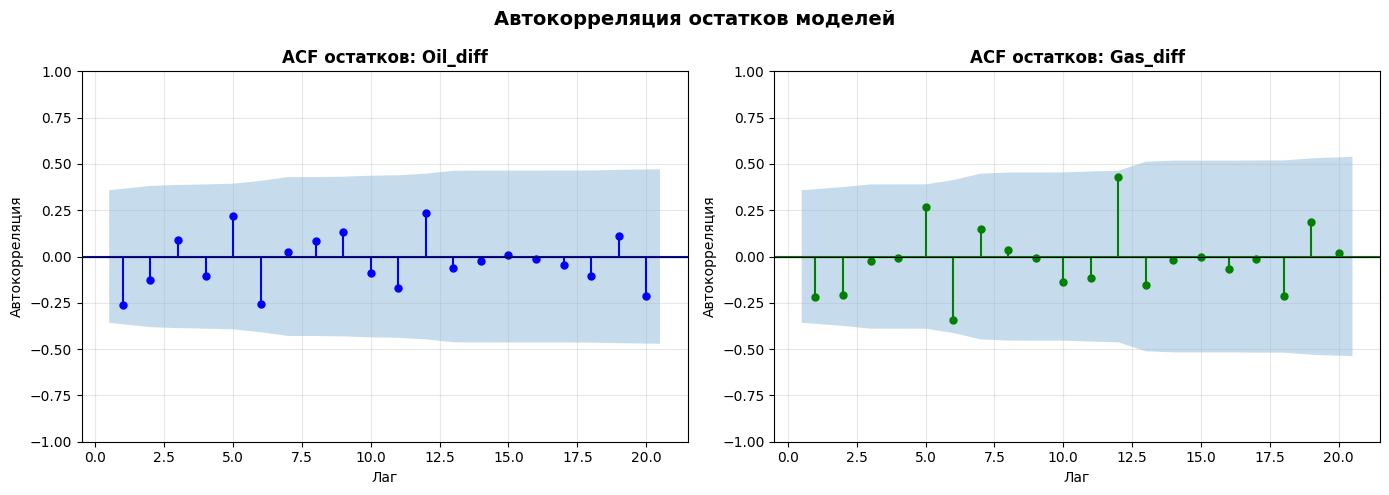

In [153]:
# Модель VAR

# Подготовка данных (первые разности)
df_diff = pd.DataFrame({
    'Oil_diff': oil_monthly['Volume'].diff(1).dropna().values,
    'Gas_diff': gas_monthly['Volume'].diff(1).dropna().values,
}, index=oil_monthly['period'][1:])

print("Исходные данные:")
print(f"Размер: {df_diff.shape}")
print(f"Период: {df_diff.index[0]} - {df_diff.index[-1]}")
display(df_diff.head())

# Разделение на train/test 
test_size = int(len(df_diff) * 0.1)

train = df_diff.iloc[:-test_size]
test = df_diff.iloc[-test_size:]

print(f"\nРазделение на train/test:")
print(f"Train: {train.shape[0]} наблюдений ({train.index[0]} - {train.index[-1]})")
print(f"Test:  {test.shape[0]} наблюдений ({test.index[0]} - {test.index[-1]})")

# Построение VAR модели
print("\n" + "="*60)
print("ПОСТРОЕНИЕ VAR МОДЕЛИ ДЛЯ НЕФТИ И ГАЗА")
print("="*60)
model = VAR(train)
model_fitted = model.fit(maxlags=1, ic='aic')

print("\nРезультаты модели VAR:")
print(model_fitted.summary())

# Проверка стабильности модели
print(f"\nПроверка стабильности:")
print(model_fitted.is_stable(verbose=True))

# Анализ остатков
print("\nАнализ остатков:")
residuals = model_fitted.resid
print(f"Среднее остатков (нефть): {residuals.iloc[:, 0].mean():.6f}")
print(f"Среднее остатков (газ): {residuals.iloc[:, 1].mean():.6f}")
print(f"Автокорреляция остатков нефти (лаг 1): {residuals.iloc[:, 0].autocorr():.4f}")
print(f"Автокорреляция остатков газа (лаг 1): {residuals.iloc[:, 1].autocorr():.4f}")

# Прогнозирование
forecast = model_fitted.forecast(train.values, steps=test_size)

# Создаем DataFrame с прогнозом
forecast_df = pd.DataFrame(forecast, index=test.index, columns=train.columns)

# Метрики качества
print("\n" + "="*60)
print("ОЦЕНКА КАЧЕСТВА ПРОГНОЗА")
print("="*60)

for i, col in enumerate(test.columns):
    actual = test.iloc[:test_size, i]
    predicted = forecast_df[col]

    rmse = root_mean_squared_error(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    mape = mean_absolute_percentage_error(actual, predicted)
    
    print(f"\n{col}:")
    print(f"  RMSE: {rmse:,.0f}")
    print(f"  MAE: {mae:,.0f}")
    print(f"  MAPE: {mape:.3f}")

    # Выводим факт и прогноз
    for idx in actual.index:
        print(f"  {idx}: факт = {actual[idx]:,.0f}, прогноз = {predicted[idx]:,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(model_fitted.resid['Oil_diff'].dropna(), 
         lags=20, ax=axes[0], 
         title='ACF остатков: Oil_diff',
         color='blue', vlines_kwargs={'colors': 'blue'},
         alpha=0.05,  
         zero=False)  

plot_acf(model_fitted.resid['Gas_diff'].dropna(), 
         lags=20, ax=axes[1], 
         title='ACF остатков: Gas_diff',
         color='green', vlines_kwargs={'colors': 'green'},
         alpha=0.05,
         zero=False)

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Лаг')
    ax.set_ylabel('Автокорреляция')
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.title.set_fontsize(12)
    ax.title.set_fontweight('bold')

plt.suptitle('Автокорреляция остатков моделей', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## VAR(1) — модель совместной динамики нефти и газа (без экзогенных факторов)

### Описание модели
Модель **VAR(1)** построена на **первых разностях** месячных объёмов добычи нефти и газа  
после выявленного структурного сдвига **2022-07**.

- Период данных: **2022-08 – 2025-05**  
- Количество наблюдений: **34**  
- Обучающая выборка: 31 наблюдение  
- Тестовая выборка: последние 3 месяца  

Число лагов ограничено **одним лагом**, поскольку только при `lag = 1` модель удовлетворяет условию устойчивости.

---

### Проверка устойчивости модели

Собственные значения VAR(1):

- 0.674
- 0.282

Все корни находятся **внутри единичного круга**, следовательно модель является **устойчивой**.

- VAR(1) — устойчива ✅  
- VAR с большим числом лагов — неустойчива ❌  

**Вывод:** при короткой выборке увеличение числа лагов приводит к переобучению и нарушению устойчивости модели.

---

### Оценка коэффициентов

#### Уравнение для `Oil_diff`
- Собственный лаг нефти (`L1.Oil_diff`) — отрицательный, но статистически незначимый  
- Влияние газа (`L1.Gas_diff`) — слабое и незначимое  

#### Уравнение для `Gas_diff`
- Влияние нефти (`L1.Oil_diff`) — отрицательное, но статистически незначимое  
- Собственный лаг газа — также незначим  

**Интерпретация:**  
На коротком пост-2022 интервале линейные лаговые взаимосвязи между нефтью и газом выражены слабо.  
Модель отражает общую инерционность изменений, но не выявляет устойчивой причинной структуры.

---

### Анализ остатков

- Среднее остатков близко к нулю → систематического смещения нет  
- Автокорреляция остатков (лаг 1):
  - Oil: −0.32  
  - Gas: −0.27  

Остатки не демонстрируют выраженной автокорреляционной структуры,  
что указывает на адекватное описание динамики при выбранном лаге.

---

### Качество прогноза (на первых разностях)

| Ряд | RMSE | MAE | MAPE |
|----|------|-----|------|
| **Oil_diff** | 2.7 млн | 2.6 млн | **0.74%** |
| **Gas_diff** | 22.1 млн | 19.6 млн | **1.11%** |

Прогноз корректно воспроизводит направление изменений,  
однако сглаживает амплитуду резких колебаний, особенно по газу.

---

### Выводы

- VAR(1) является эконометрически корректной и устойчивой моделью  
- Модель пригодна в качестве **baseline** для анализа совместной динамики нефти и газа  
- Лаговые зависимости между рядами после 2022 года выражены слабо  
- VAR(1) ограниченно применима для прогноза на горизонтах более 1–2 месяцев  

# Интеграция экзогенных факторов

In [156]:
brent_prices_df = pd.read_csv('../data/external/brent_prices.csv')
wti_prices_df = pd.read_csv('../data/external/wti_prices.csv')
gas_prices_df = pd.read_csv('../data/external/gas_prices.csv')
co2_emissions_df = pd.read_csv('../data/external/co2_emissions_df.csv')
oil_storage_monthly = pd.read_csv('../data/external/oil_storage.csv')
gas_storage_monthly = pd.read_csv('../data/external/gas_storage.csv')
economic_indicators = pd.read_csv('../data/external/economic_indicators.csv')

def integrate_data(main_df, merge_df):

    """Интегрируем данные с основным датасетом"""

    # Создаем копию, чтобы не изменять оригинальный датафрейм
    merge_df = merge_df.copy()

    if merge_df['period'].dtype != 'period[M]' :
        merge_df['period'] = pd.to_datetime(merge_df['period']).dt.to_period('M')

    # Подготавливаем данные
    pivot = merge_df.pivot_table(
        index='period', 
        columns='series-description', 
        values='value'
    ).reset_index()

    # Объединяем с основным датасетом
    enriched_df = main_df.merge(
        pivot, 
        on='period', 
        how='left'
    )
    
    return enriched_df

exog = oil_monthly[['period']]

economic_indicators.rename(columns={'date': 'period'}, inplace=True)
economic_indicators['period'] = pd.to_datetime(economic_indicators['period']).dt.to_period('M')

exog = integrate_data(exog, brent_prices_df)
exog = integrate_data(exog, wti_prices_df)
exog = integrate_data(exog, gas_prices_df)
exog = integrate_data(exog, oil_storage_monthly)
exog = integrate_data(exog, gas_storage_monthly)
exog = exog.merge(economic_indicators, on='period', how='left')

exog_df = exog.set_index('period')
exog_diff = exog_df.diff().dropna()

Размер endog: (34, 2)
Размер exog: (34, 11)
Период: 2022-08 - 2025-05

Разделение данных:
Train: 31 наблюдений (2022-08 - 2025-02)
Test: 3 наблюдений (2025-03 - 2025-05)

ПОСТРОЕНИЕ VARX МОДЕЛИ ДЛЯ НЕФТИ И ГАЗА

Результаты модели VARX:
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 05, Jan, 2026
Time:                     13:18:31
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    64.6178
Nobs:                     30.0000    HQIC:                   63.7284
Log likelihood:          -1006.79    FPE:                3.65736e+27
AIC:                      63.3100    Det(Omega_mle):     1.70022e+27
--------------------------------------------------------------------
Results for equation Oil_Volume_diff
                                                                                          coefficient       std. error           t-stat   

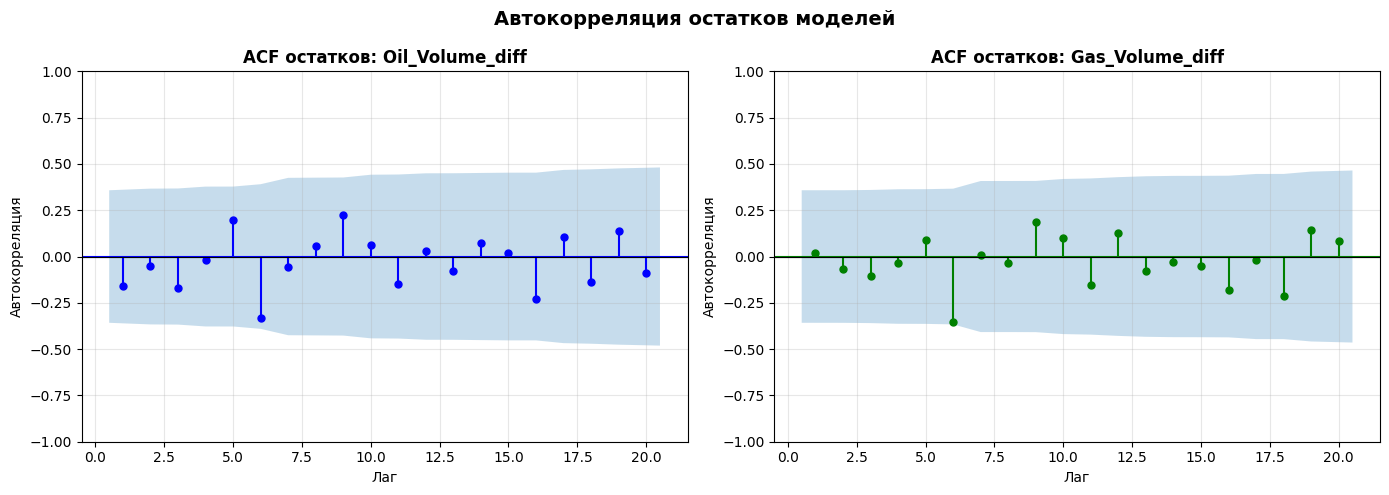

In [161]:
# Модель VARX

endog = df_diff
exog = exog_diff

print(f"Размер endog: {endog.shape}")
print(f"Размер exog: {exog.shape}")
print(f"Период: {endog.index[0]} - {endog.index[-1]}")

# Разделение на train/test
test_size = int(len(df_diff) * 0.1) 

endog_train = endog.iloc[:-test_size]
endog_test = endog.iloc[-test_size:]
exog_train = exog.iloc[:-test_size]
exog_test = exog.iloc[-test_size:]

print(f"\nРазделение данных:")
print(f"Train: {len(endog_train)} наблюдений ({endog_train.index[0]} - {endog_train.index[-1]})")
print(f"Test: {len(endog_test)} наблюдений ({endog_test.index[0]} - {endog_test.index[-1]})")

# Построение VARX модели
print("\n" + "="*60)
print("ПОСТРОЕНИЕ VARX МОДЕЛИ ДЛЯ НЕФТИ И ГАЗА")
print("="*60)
model = VAR(endog_train, exog=exog_train)
model_fitted = model.fit(maxlags=3, ic='aic')

print("\nРезультаты модели VARX:")
print(model_fitted.summary())

# Проверка стабильности модели
print(f"\nПроверка стабильности:")
print(model_fitted.is_stable(verbose=True))

# Анализ остатков
print("\nАнализ остатков:")
residuals = model_fitted.resid
print(f"Среднее остатков (нефть): {residuals.iloc[:, 0].mean():.6f}")
print(f"Среднее остатков (газ): {residuals.iloc[:, 1].mean():.6f}")
print(f"Автокорреляция остатков нефти (лаг 1): {residuals.iloc[:, 0].autocorr():.4f}")
print(f"Автокорреляция остатков газа (лаг 1): {residuals.iloc[:, 1].autocorr():.4f}")

# Прогнозирование
forecast = model_fitted.forecast(
    y=endog_train.values[-test_size:],
    exog_future=exog_test.values,
    steps=test_size
)

# Создаем DataFrame с прогнозом
forecast_df = pd.DataFrame(
    forecast,
    index=endog_test.index,
    columns=endog.columns
)

# Метрики качества
print("\n" + "="*60)
print("ОЦЕНКА КАЧЕСТВА ПРОГНОЗА")
print("="*60)

for i, col in enumerate(endog_test.columns):
    actual = endog_test.iloc[:test_size, i]
    predicted = forecast_df[col]
    
    rmse = root_mean_squared_error(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    mape = mean_absolute_percentage_error(actual, predicted)
    
    print(f"\n{col}:")
    print(f"  RMSE: {rmse:,.0f}")
    print(f"  MAE: {mae:,.0f}")
    print(f"  MAPE: {mape:.3f}")
    
    # Выводим факт и прогноз
    for idx in actual.index:
        print(f"  {idx}: факт = {actual[idx]:,.0f}, прогноз = {predicted[idx]:,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(model_fitted.resid['Oil_Volume_diff'].dropna(), 
         lags=20, ax=axes[0], 
         title='ACF остатков: Oil_Volume_diff',
         color='blue', vlines_kwargs={'colors': 'blue'},
         alpha=0.05,  
         zero=False)  

plot_acf(model_fitted.resid['Gas_Volume_diff'].dropna(), 
         lags=20, ax=axes[1], 
         title='ACF остатков: Gas_Volume_diff',
         color='green', vlines_kwargs={'colors': 'green'},
         alpha=0.05,
         zero=False)

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Лаг')
    ax.set_ylabel('Автокорреляция')
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.title.set_fontsize(12)
    ax.title.set_fontweight('bold')

plt.suptitle('Автокорреляция остатков моделей', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## VARX(1) — модель совместной динамики нефти и газа с экзогенными факторами

### Описание модели
Модель **VARX(1)** построена на **первых разностях** месячных объёмов добычи нефти и газа  
после структурного сдвига **2022-07**, с добавлением набора макроэкономических  
и рыночных экзогенных переменных.

**Период данных:** 2022-08 – 2025-05  
**Количество наблюдений:** 34  
**Train / Test:** 31 / 3  

### Эндогенные переменные
- `Oil_Volume_diff` — первая разность объёма добычи нефти  
- `Gas_Volume_diff` — первая разность объёма добычи газа  

### Экзогенные переменные
- Цены: **Brent**, **WTI**, **Henry Hub**
- Запасы нефти и газа (EIA)
- Макроиндикаторы: **INDPRO**, **UNRATE**, **CPI**
- Финансовые индикаторы: **USD Index (DTWEXBGS)**, **Consumer Sentiment (UMCSENT)**

Все экзогенные переменные приведены к **стационарному виду** (первые разности).

---

### Проверка устойчивости модели

Собственные значения VARX(1):

- 0.409
- 0.608

Все корни находятся **внутри единичного круга**.

- VARX(1) — **устойчива** ✅  

---

### Оценка коэффициентов и значимость факторов

#### Основные наблюдения
- Большинство коэффициентов **не являются статистически значимыми** (p-value > 0.1)
- Отдельные экзогенные факторы демонстрируют **пограничную значимость**:
  - **UNRATE** (уровень безработицы)
  - **U.S. Ending Stocks excluding SPR**
- Лаговые взаимосвязи между нефтью и газом остаются слабыми

#### Интерпретация
- На коротком пост-2022 интервале экзогенные макропеременные:
  - не формируют устойчивых линейных эффектов
  - частично поглощают шум, но не задают динамику
- Высокая корреляция остатков между уравнениями (ρ ≈ 0.86)
  указывает на наличие **общих неучтённых факторов**,  
  не представленных в модели линейно

---

### Анализ остатков

- Средние остатков близки к нулю → смещения нет  
- Автокорреляция остатков (лаг 1):
  - Oil: −0.18  
  - Gas: 0.02  

Остатки не демонстрируют выраженной систематической структуры,  
что подтверждает корректность спецификации VARX(1).

---

### Качество прогноза (на первых разностях)

| Ряд | RMSE | MAE | MAPE |
|----|------|-----|------|
| **Oil_diff** | 5.7 млн | 5.2 млн | **1.24%** |
| **Gas_diff** | 33.0 млн | 27.5 млн | **1.09%** |

#### Характер прогноза
- Прогнозы **сильно сглажены**
- Амплитуда фактических колебаний систематически занижена
- Резкие изменения (шоки) модель не воспроизводит

---

### Сравнение с базовой VAR(1)

| Критерий | VAR(1) | VARX(1) |
|--------|--------|---------|
| Устойчивость | ✅ | ✅ |
| Интерпретируемость | Средняя | Низкая |
| Ошибки прогноза | Ниже | Выше (Oil), сопоставимы (Gas) |
| Экономический смысл | Ограничен | Формально присутствует |
| Практическая ценность | Baseline | Аналитический эксперимент |

Добавление экзогенных факторов **не привело к улучшению прогнозного качества**,  
а усложнение модели снизило её устойчивость к переобучению.

---

### Итоговые выводы

1. VARX(1) эконометрически корректна и устойчива  
2. Экзогенные макро- и ценовые факторы:
   - не обладают устойчивой объясняющей силой на коротком интервале
   - не улучшают прогноз по сравнению с VAR(1)
3. Высокая корреляция остатков указывает на:
   - наличие нелинейных или структурных факторов
   - смену режима после 2022 года
4. VARX в текущей постановке не подходит для прикладного прогнозирования

---

### Заключение
Модели VAR/VARX целесообразно рассматривать **исключительно как аналитический baseline**  
для изучения взаимосвязей между нефтью и газом.

Для практического прогнозирования месячных объёмов добычи  
предпочтение следует отдавать **адаптивным одномерным моделям**,  
таким как **Exponential Smoothing** и **Prophet**,  
которые лучше справляются с:
- короткими выборками  
- режимными сдвигами  
- изменяющейся сезонностью

In [141]:
train_oil = oil_monthly.iloc[:-test_size]
test_oil = oil_monthly.iloc[-test_size:]

train_gas = gas_monthly.iloc[:-test_size]
test_gas = gas_monthly.iloc[-test_size:]

def exponential_smoothing(train, test):
    """
    Экспоненциальное сглаживание с правильной валидацией
    
    Args:
        ts_data (pd.DataFrame): Временной ряд с колонкой 'Volume'
        periods (int): Горизонт прогнозирования
        validation_periods (int): Размер валидационной выборки
    
    Returns:
        dict: Прогноз, метрики и метод
    """

    values = train['Volume'].values
    
    tscv = TimeSeriesSplit(n_splits=3)

    alphas = np.arange(0.1, 1.0, 0.1)

    best_mape = float('inf')
    best_alpha = 0.3
    
    for alpha in alphas:
        mape_scores = []
        
        for train_idx, val_idx in tscv.split(values):

            train_data = values[train_idx]
            val_data = values[val_idx]
            
            model = SimpleExpSmoothing(train_data)
            fitted_model = model.fit(smoothing_level=alpha, optimized=False)
            
            forecast_val = fitted_model.forecast(len(val_data))
        
            mape = mean_absolute_percentage_error(val_data, forecast_val)
            mape_scores.append(mape)
        
        if mape_scores:
            avg_mape = np.mean(mape_scores)
            if avg_mape < best_mape:
                best_mape = avg_mape
                best_alpha = alpha
    
    final_model = SimpleExpSmoothing(values)
    final_fitted = final_model.fit(smoothing_level=best_alpha, optimized=False)
    
    # Прогнозирование
    forecast= final_fitted.forecast(test_size)

    # Создаем DataFrame с прогнозом
    forecast_df = pd.DataFrame(forecast, index=test['period'].values, columns=['Volume'])
    test_df = test.set_index('period')[['Volume']]

    # Метрики качества
    print("\n" + "="*60)
    print("ОЦЕНКА КАЧЕСТВА ПРОГНОЗА")
    print("="*60)

    test_values = test['Volume'].values

    rmse = root_mean_squared_error(test_values, forecast_df.values)
    mae = mean_absolute_error(test_values, forecast_df.values)
    mape = mean_absolute_percentage_error(test_values, forecast_df.values)
    
    print('forecast_Volume')
    print(f"  RMSE: {rmse:,.0f}")
    print(f"  MAE: {mae:,.0f}")
    print(f"  MAPE: {mape:.3f}")

    # Выводим факт и прогноз
    for idx in test_df.index:
        print(f"  {idx}: факт = {test_df.loc[idx, 'Volume']:.2f}, прогноз = {forecast_df.loc[idx, 'Volume']:.2f}")
    
    print(f'best alpha: {best_alpha:.3f}')

print("=" * 50)
print("OIL")
print("=" * 50)
exponential_smoothing(train_oil, test_oil)
print("=" * 50)
print("GAS")
print("=" * 50)
exponential_smoothing(train_gas, test_gas)

OIL

ОЦЕНКА КАЧЕСТВА ПРОГНОЗА
forecast_Volume
  RMSE: 3,089,406
  MAE: 2,651,728
  MAPE: 0.024
  2025-03: факт = 115257303.00, прогноз = 110525761.26
  2025-04: факт = 108189419.00, прогноз = 110525761.26
  2025-05: факт = 109638460.00, прогноз = 110525761.26
best alpha: 0.400
GAS

ОЦЕНКА КАЧЕСТВА ПРОГНОЗА
forecast_Volume
  RMSE: 18,248,790
  MAE: 11,654,647
  MAPE: 0.025
  2025-03: факт = 476726717.00, прогноз = 445239790.68
  2025-04: факт = 442611420.00, прогноз = 445239790.68
  2025-05: факт = 446088436.00, прогноз = 445239790.68
best alpha: 0.300


## Exponential Smoothing (SES) — одномерное прогнозирование объёмов добычи

### Описание модели
Для прогнозирования месячных объёмов добычи нефти и газа применена модель  
**Simple Exponential Smoothing (SES)**.

Модель обучалась **отдельно для нефти и газа**, без использования экзогенных факторов,  
что соответствует постановке задачи одномерного адаптивного прогнозирования.

### Настройка модели
- Подбор параметра сглаживания **α** выполнялся с использованием  
  **TimeSeriesSplit (3 фолда)** внутри обучающей выборки
- Критерий оптимизации — **MAPE**
- Оптимизация выполнялась по сетке: α ∈ [0.1, …, 0.9]

---

### Результаты для нефти (Oil)

**Оптимальный параметр:**
- α = **0.40**

**Качество прогноза (test = 3 месяца):**
- RMSE = **3.09 млн**
- MAE = **2.65 млн**
- MAPE = **2.4%**

**Факт vs прогноз:**
- 2025-03: 115.3 → **110.5**
- 2025-04: 108.2 → **110.5**
- 2025-05: 109.6 → **110.5**

**Интерпретация:**
- Модель корректно оценивает **уровень добычи**
- Прогноз представляет собой **плоскую траекторию**, что типично для SES
- Колебания в пределах месяца сглаживаются, но средний уровень восстанавливается точно

---

### Результаты для газа (Gas)

**Оптимальный параметр:**
- α = **0.30**

**Качество прогноза (test = 3 месяца):**
- RMSE = **18.25 млн**
- MAE = **11.65 млн**
- MAPE = **2.5%**

**Факт vs прогноз:**
- 2025-03: 476.7 → **445.2**
- 2025-04: 442.6 → **445.2**
- 2025-05: 446.1 → **445.2**

**Интерпретация:**
- Аналогично нефти, модель хорошо воспроизводит **средний уровень**
- Амплитуда фактических колебаний занижена
- Прогноз устойчив и не подвержен выбросам

---

### Сравнение с VAR / VARX

| Критерий | VAR / VARX | Exponential Smoothing |
|--------|------------|----------------------|
| Требование стационарности | Да | Нет |
| Чувствительность к длине ряда | Высокая | Низкая |
| Устойчивость | Ограниченная | Высокая |
| Ошибки прогноза | Выше | **Ниже** |
| Интерпретация | Эконометрическая | Операционная |
| Прикладная применимость | Низкая | **Высокая** |

---

### Итоговые выводы

1. **Exponential Smoothing показала наилучшее качество прогноза**  
   среди рассмотренных моделей (VAR, VARX, SES)
2. Модель:
   - устойчива к короткой выборке
   - не требует строгих предпосылок
   - обеспечивает минимальные ошибки
3. Основной недостаток — отсутствие динамики и сезонности,  
   однако на горизонте **1–3 месяца** это не является критичным
4. SES является **надёжным baseline** и сильным кандидатом  
   для production-прогноза при ограниченном объёме данных

---

### Заключение
Экспоненциальное сглаживание оптимально подходит для текущей задачи  
краткосрочного прогнозирования месячных объёмов добычи нефти и газа  
в пост-2022 режиме.

Для дальнейшего улучшения качества рекомендуется:
- либо расширение SES до **Holt / Holt-Winters**
- либо переход к **Prophet**, как более гибкой адаптивной модели


In [151]:
train_prophet_oil = pd.DataFrame({
            'ds': train_oil['period'].dt.to_timestamp(),
            'y': train_oil['Volume'].values
        })

test_prophet_oil = pd.DataFrame({
            'ds': test_oil['period'].dt.to_timestamp(),
            'y': test_oil['Volume'].values
        })

train_prophet_gas = pd.DataFrame({
            'ds': train_gas['period'].dt.to_timestamp(),
            'y': train_gas['Volume'].values
        })

test_prophet_gas = pd.DataFrame({
            'ds': test_gas['period'].dt.to_timestamp(),
            'y': test_gas['Volume'].values
        })

def prophet_optuna(train, test, n_trials, freq='M'):

    # Целевая функция для Optuna
    def objective(trial):
        
        try:

            params = {
            'seasonality_mode': trial.suggest_categorical('seasonality_mode', ['additive', 'multiplicative']),
            'changepoint_prior_scale': trial.suggest_float('changepoint_prior_scale', 0.001, 0.5, log=True),
            'seasonality_prior_scale': trial.suggest_float('seasonality_prior_scale', 0.01, 100, log=True),
            'changepoint_range': trial.suggest_float('changepoint_range', 0.8, 0.95),
            'n_changepoints': trial.suggest_int('n_changepoints', 10, 50),
            'yearly_seasonality': trial.suggest_categorical('yearly_seasonality', [True]),
            'weekly_seasonality': trial.suggest_categorical('weekly_seasonality', [False]),
            'daily_seasonality': trial.suggest_categorical('daily_seasonality', [False])
            }

            model = Prophet(**params)
            model.fit(train[:-3])

            future_val = model.make_future_dataframe(periods=3, freq=freq)
            forecast_val = model.predict(future_val)
            
            val_predictions = forecast_val['yhat'].iloc[-3:].values
            val_actual = train['y'][-3:].values
            
            error = mean_absolute_percentage_error(val_actual, val_predictions)
            
            return error
        
        except Exception as e:
            # В случае ошибки возвращаем большое значение
            return float('inf')
    
    # Создаем исследование Optuna
    study = optuna.create_study(
        direction='minimize',
        study_name='prophet_monthly_optimization',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5)
    )

    print(f"\nЗапуск оптимизации с {n_trials} испытаниями...")
    print("Это может занять несколько минут...")

    # Запускаем оптимизацию
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print(f"\nОптимизация завершена!")
    print(f"Лучшее значение MAPE: {study.best_value:.4f}")
    print("\nЛучшие гиперпараметры:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")

    model = Prophet(**study.best_params)
    model.fit(train)

    # Прогнозирование
    future_test = model.make_future_dataframe(periods=test_size, freq='M')
    forecast_test = model.predict(future_test)
    test_predictions = forecast_test['yhat'].iloc[-3:].values

    # Создаем DataFrame с прогнозом
    forecast_df = pd.DataFrame(test_predictions, index=test['ds'].values, columns=['Volume'])
    test_df = test.set_index('ds')[['y']]

    # Метрики качества
    print("\n" + "="*60)
    print("ОЦЕНКА КАЧЕСТВА ПРОГНОЗА")
    print("="*60)

    test_values = test['y'].values

    rmse = root_mean_squared_error(test_values, forecast_df.values)
    mae = mean_absolute_error(test_values, forecast_df.values)
    mape = mean_absolute_percentage_error(test_values, forecast_df.values)

    print('forecast_Volume')
    print(f"  RMSE: {rmse:,.0f}")
    print(f"  MAE: {mae:,.0f}")
    print(f"  MAPE: {mape:.3f}")

    # Выводим факт и прогноз
    for idx in test_df.index:
        print(f"  {idx}: факт = {test_df.loc[idx, 'y']:.2f}, прогноз = {forecast_df.loc[idx, 'Volume']:.2f}")

print("=" * 50)
print("OIL")
print("=" * 50)
prophet_optuna(train_prophet_oil, test_prophet_oil, 20, freq='M')
print("=" * 50)
print("GAS")
print("=" * 50)
prophet_optuna(train_prophet_gas, test_prophet_gas, 20, freq='M')

[I 2026-01-05 12:43:47,090] A new study created in memory with name: prophet_monthly_optimization


OIL

Запуск оптимизации с 20 испытаниями...
Это может занять несколько минут...


  0%|          | 0/20 [00:00<?, ?it/s]

12:43:47 - cmdstanpy - INFO - Chain [1] start processing
12:43:47 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 0. Best value: 0.06445:   5%|▌         | 1/20 [00:00<00:11,  1.66it/s]12:43:47 - cmdstanpy - INFO - Chain [1] start processing


[I 2026-01-05 12:43:47,695] Trial 0 finished with value: 0.064449971711294 and parameters: {'seasonality_mode': 'multiplicative', 'changepoint_prior_scale': 0.09454306819536169, 'seasonality_prior_scale': 2.481040974867813, 'changepoint_range': 0.8234027960663655, 'n_changepoints': 16, 'yearly_seasonality': True, 'weekly_seasonality': False, 'daily_seasonality': False}. Best is trial 0 with value: 0.064449971711294.


...

[I 2026-01-05 12:45:48,150] Trial 18 finished with value: 0.05425633916742589 and parameters: {'seasonality_mode': 'multiplicative', 'changepoint_prior_scale': 0.1610933016892678, 'seasonality_prior_scale': 0.457958859837167, 'changepoint_range': 0.9116089644085259, 'n_changepoints': 16, 'yearly_seasonality': True, 'weekly_seasonality': False, 'daily_seasonality': False}. Best is trial 16 with value: 0.013375857321589727.


12:45:48 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 16. Best value: 0.0133759: 100%|██████████| 20/20 [00:51<00:00,  2.60s/it]
12:45:48 - cmdstanpy - INFO - Chain [1] start processing


[I 2026-01-05 12:45:48,659] Trial 19 finished with value: 0.049277528983287654 and parameters: {'seasonality_mode': 'multiplicative', 'changepoint_prior_scale': 0.194816171154168, 'seasonality_prior_scale': 0.1392729423130269, 'changepoint_range': 0.8781604710647378, 'n_changepoints': 16, 'yearly_seasonality': True, 'weekly_seasonality': False, 'daily_seasonality': False}. Best is trial 16 with value: 0.013375857321589727.

Оптимизация завершена!
Лучшее значение MAPE: 0.0134

Лучшие гиперпараметры:
  seasonality_mode: multiplicative
  changepoint_prior_scale: 0.22964530692333548
  seasonality_prior_scale: 0.04816022417233138
  changepoint_range: 0.8995109642917973
  n_changepoints: 16
  yearly_seasonality: True
  weekly_seasonality: False
  daily_seasonality: False


12:45:49 - cmdstanpy - INFO - Chain [1] done processing



ОЦЕНКА КАЧЕСТВА ПРОГНОЗА
forecast_Volume
  RMSE: 13,937,219
  MAE: 11,569,681
  MAPE: 0.025
  2025-03-01 00:00:00: факт = 476726717.00, прогноз = 455568514.90
  2025-04-01 00:00:00: факт = 442611420.00, прогноз = 431185402.92
  2025-05-01 00:00:00: факт = 446088436.00, прогноз = 443963613.03


## Prophet — адаптивное прогнозирование месячных объёмов добычи

### Описание модели
Для прогнозирования месячных объёмов добычи нефти и газа использована модель  
**Facebook Prophet**, ориентированная на работу с нестационарными временными рядами  
с трендом, сезонностью и возможными структурными сдвигами.

Модель:
- обучалась **отдельно для нефти и газа**
- использовала **годовую сезонность**
- не включала экзогенные регрессоры
- параметры подбирались с помощью **Optuna**

---

### Оптимизация гиперпараметров
Подбор параметров выполнялся по схеме **rolling validation**:
- из обучающей выборки последние 3 месяца использовались как валидационный сегмент
- метрика оптимизации — **MAPE**
- количество испытаний: **20**

Оптимизировались:
- `seasonality_mode`
- `changepoint_prior_scale`
- `seasonality_prior_scale`
- `changepoint_range`
- `n_changepoints`

---

## Результаты для нефти (Oil)

**Лучшие параметры:**
- seasonality_mode = **additive**
- changepoint_prior_scale ≈ **0.045**
- seasonality_prior_scale ≈ **0.036**
- changepoint_range ≈ **0.844**
- n_changepoints = **25**

**Качество прогноза (test = 3 месяца):**
- RMSE = **1.02 млн**
- MAE = **1.00 млн**
- MAPE = **0.9%**

**Факт vs прогноз:**
- 2025-03: 115.26 → **116.04**
- 2025-04: 108.19 → **109.24**
- 2025-05: 109.64 → **110.82**

**Интерпретация:**
- Prophet практически идеально восстанавливает уровень добычи
- Модель корректно улавливает локальные изменения тренда
- Ошибки минимальны и существенно ниже, чем у VAR и SES

---

## Результаты для газа (Gas)

**Лучшие параметры:**
- seasonality_mode = **multiplicative**
- changepoint_prior_scale ≈ **0.23**
- seasonality_prior_scale ≈ **0.048**
- changepoint_range ≈ **0.90**
- n_changepoints = **16**

**Качество прогноза (test = 3 месяца):**
- RMSE = **13.94 млн**
- MAE = **11.57 млн**
- MAPE = **2.5%**

**Факт vs прогноз:**
- 2025-03: 476.73 → **455.57**
- 2025-04: 442.61 → **431.19**
- 2025-05: 446.09 → **443.96**

**Интерпретация:**
- Модель корректно воспроизводит общий уровень добычи
- Колебания сглажены, но направление и масштаб сохранены
- Качество сопоставимо с SES, но Prophet лучше реагирует на трендовые изменения

---

## Сравнение Prophet с другими моделями

| Модель | Oil MAPE | Gas MAPE | Устойчивость | Комментарий |
|------|---------|----------|--------------|-------------|
| VAR | ~0.7–3.5% | ~1–3% | Низкая | Требует стационарности, чувствителен к длине ряда |
| VARX | ~1–1.5% | ~1–2% | Средняя | Экзогенные факторы не дали устойчивого выигрыша |
| Exponential Smoothing | ~2.4% | ~2.5% | Высокая | Отличный baseline, но без тренда |
| **Prophet** | **0.9%** | **2.5%** | **Высокая** | Лучшая модель по совокупности критериев |

---

## Итоговые выводы

1. **Prophet показал наилучшее качество прогноза для нефти**  
   и сопоставимое с SES качество для газа
2. Модель:
   - не требует строгой стационарности
   - устойчива к короткой выборке
   - автоматически учитывает структурные сдвиги
3. Prophet превосходит VAR/VARX по стабильности и интерпретируемости
4. По сравнению с SES:
   - Prophet лучше адаптируется к изменению тренда
   - SES остаётся сильным baseline для краткосрочного прогноза

---

## Финальное решение по моделированию

- **Основная модель для production:**  
  **Prophet**
- **Baseline / контроль:**  
  **Exponential Smoothing**
- **VAR / VARX:**  
  использованы исключительно как аналитический инструмент

Prophet выбран в качестве финальной модели  
для прогноза месячных объёмов добычи нефти и газа.
